# Plot well correlation to DMSO per plate
1. Plate maps: each well colored by its Pearson correlation to the plate's DMSO profile, one panel per plate (patient). DMSO wells are outlined; outer wells are the ring of rows B/G and columns 2/11.
2. Correlation to DMSO per treatment across plates.

In [1]:
list_of_packages <- c("ggplot2", "dplyr", "arrow", "RColorBrewer")
for (package in list_of_packages) {
    suppressPackageStartupMessages(
        suppressWarnings(
            library(package, character.only = TRUE, quietly = TRUE, warn.conflicts = FALSE)
        )
    )
}

find_git_root <- function() {
    cwd <- getwd()
    if (dir.exists(file.path(cwd, ".git"))) {
        return(cwd)
    }
    current_path <- cwd
    while (dirname(current_path) != current_path) {
        parent_path <- dirname(current_path)
        if (dir.exists(file.path(parent_path, ".git"))) {
            return(parent_path)
        }
        current_path <- parent_path
    }
    stop("No Git root directory found.")
}

root_dir <- find_git_root()
source(file.path(root_dir, "utils", "r_plot_themes.r"))
source(file.path(root_dir, "utils", "r_plot_funcs.r"))

In [2]:
results_dir <- file.path(root_dir, "5.differential_analysis", "results")
figures_dir <- file.path(root_dir, "5.differential_analysis", "figures")
dir.create(figures_dir, recursive = TRUE, showWarnings = FALSE)

correlation_path <- file.path(results_dir, "well_dmso_correlation.parquet")
plate_map_path <- file.path(figures_dir, "plate_well_dmso_correlation.pdf")
treatment_figure_path <- file.path(figures_dir, "well_dmso_correlation_by_treatment.pdf")

compartment_labels <- c(organoid = "Organoid", single_cell = "Single cell")
tumor_type_levels <- c("cNF", "pNF", "MPNST", "Other")

In [3]:
correlation_df <- read_parquet(correlation_path) %>%
    mutate(
        compartment_label = factor(compartment_labels[compartment], levels = compartment_labels),
        Metadata_Plate_Row = factor(Metadata_Plate_Row, levels = rev(LETTERS[1:8])),
        Metadata_Plate_Column = factor(Metadata_Plate_Column, levels = 1:12),
        is_dmso = Metadata_Experiment_Treatment == "DMSO",
        Metadata_Biology_TumorType = factor(Metadata_Biology_TumorType, levels = tumor_type_levels),
        patient_label = paste0(Metadata_Biology_PatientTumor, " (", Metadata_Biology_TumorType, ")"),
        treatment_label = paste0(
            Metadata_Experiment_Treatment, " ",
            as.character(Metadata_Experiment_Dose), " ",
            Metadata_Experiment_Unit
        )
    )
patient_levels <- correlation_df %>%
    distinct(patient_label, Metadata_Biology_TumorType, Metadata_Biology_PatientTumor) %>%
    arrange(match(Metadata_Biology_TumorType, tumor_type_levels), Metadata_Biology_PatientTumor) %>%
    pull(patient_label)
correlation_df$patient_label <- factor(correlation_df$patient_label, levels = patient_levels)

treatment_levels <- correlation_df %>%
    distinct(Metadata_Experiment_Treatment, Metadata_Experiment_Dose, treatment_label) %>%
    arrange(match(Metadata_Experiment_Treatment, custom_treatment_order), Metadata_Experiment_Dose) %>%
    pull(treatment_label)
correlation_df$treatment_label <- factor(correlation_df$treatment_label, levels = treatment_levels)
head(correlation_df)

Metadata_Biology_PatientTumor,Metadata_Biology_TumorType,Metadata_Experiment_Well,Metadata_Experiment_Treatment,Metadata_Experiment_Dose,Metadata_Experiment_Unit,compartment,correlation_to_dmso,Metadata_Plate_Row,Metadata_Plate_Column,Metadata_Plate_Position,compartment_label,is_dmso,patient_label,treatment_label
<chr>,<fct>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<fct>,<fct>,<chr>,<fct>,<lgl>,<fct>,<fct>
NF0014_T1,cNF,C10,Trametinib,1,uM,organoid,-0.06255543,C,10,inner,Organoid,FALSE,NF0014_T1 (cNF),Trametinib 1 uM
NF0014_T1,cNF,C11,Staurosporine,10,nM,organoid,-0.09223834,C,11,outer,Organoid,FALSE,NF0014_T1 (cNF),Staurosporine 10 nM
NF0014_T1,cNF,C2,Staurosporine,10,nM,organoid,-0.51563292,C,2,outer,Organoid,FALSE,NF0014_T1 (cNF),Staurosporine 10 nM
NF0014_T1,cNF,C3,Onalespib,1,uM,organoid,-0.23391493,C,3,inner,Organoid,FALSE,NF0014_T1 (cNF),Onalespib 1 uM
NF0014_T1,cNF,C4,DMSO,1,%,organoid,0.13546395,C,4,inner,Organoid,TRUE,NF0014_T1 (cNF),DMSO 1 %
NF0014_T1,cNF,C5,Everolimus,1,uM,organoid,0.26660062,C,5,inner,Organoid,FALSE,NF0014_T1 (cNF),Everolimus 1 uM


## Plate maps

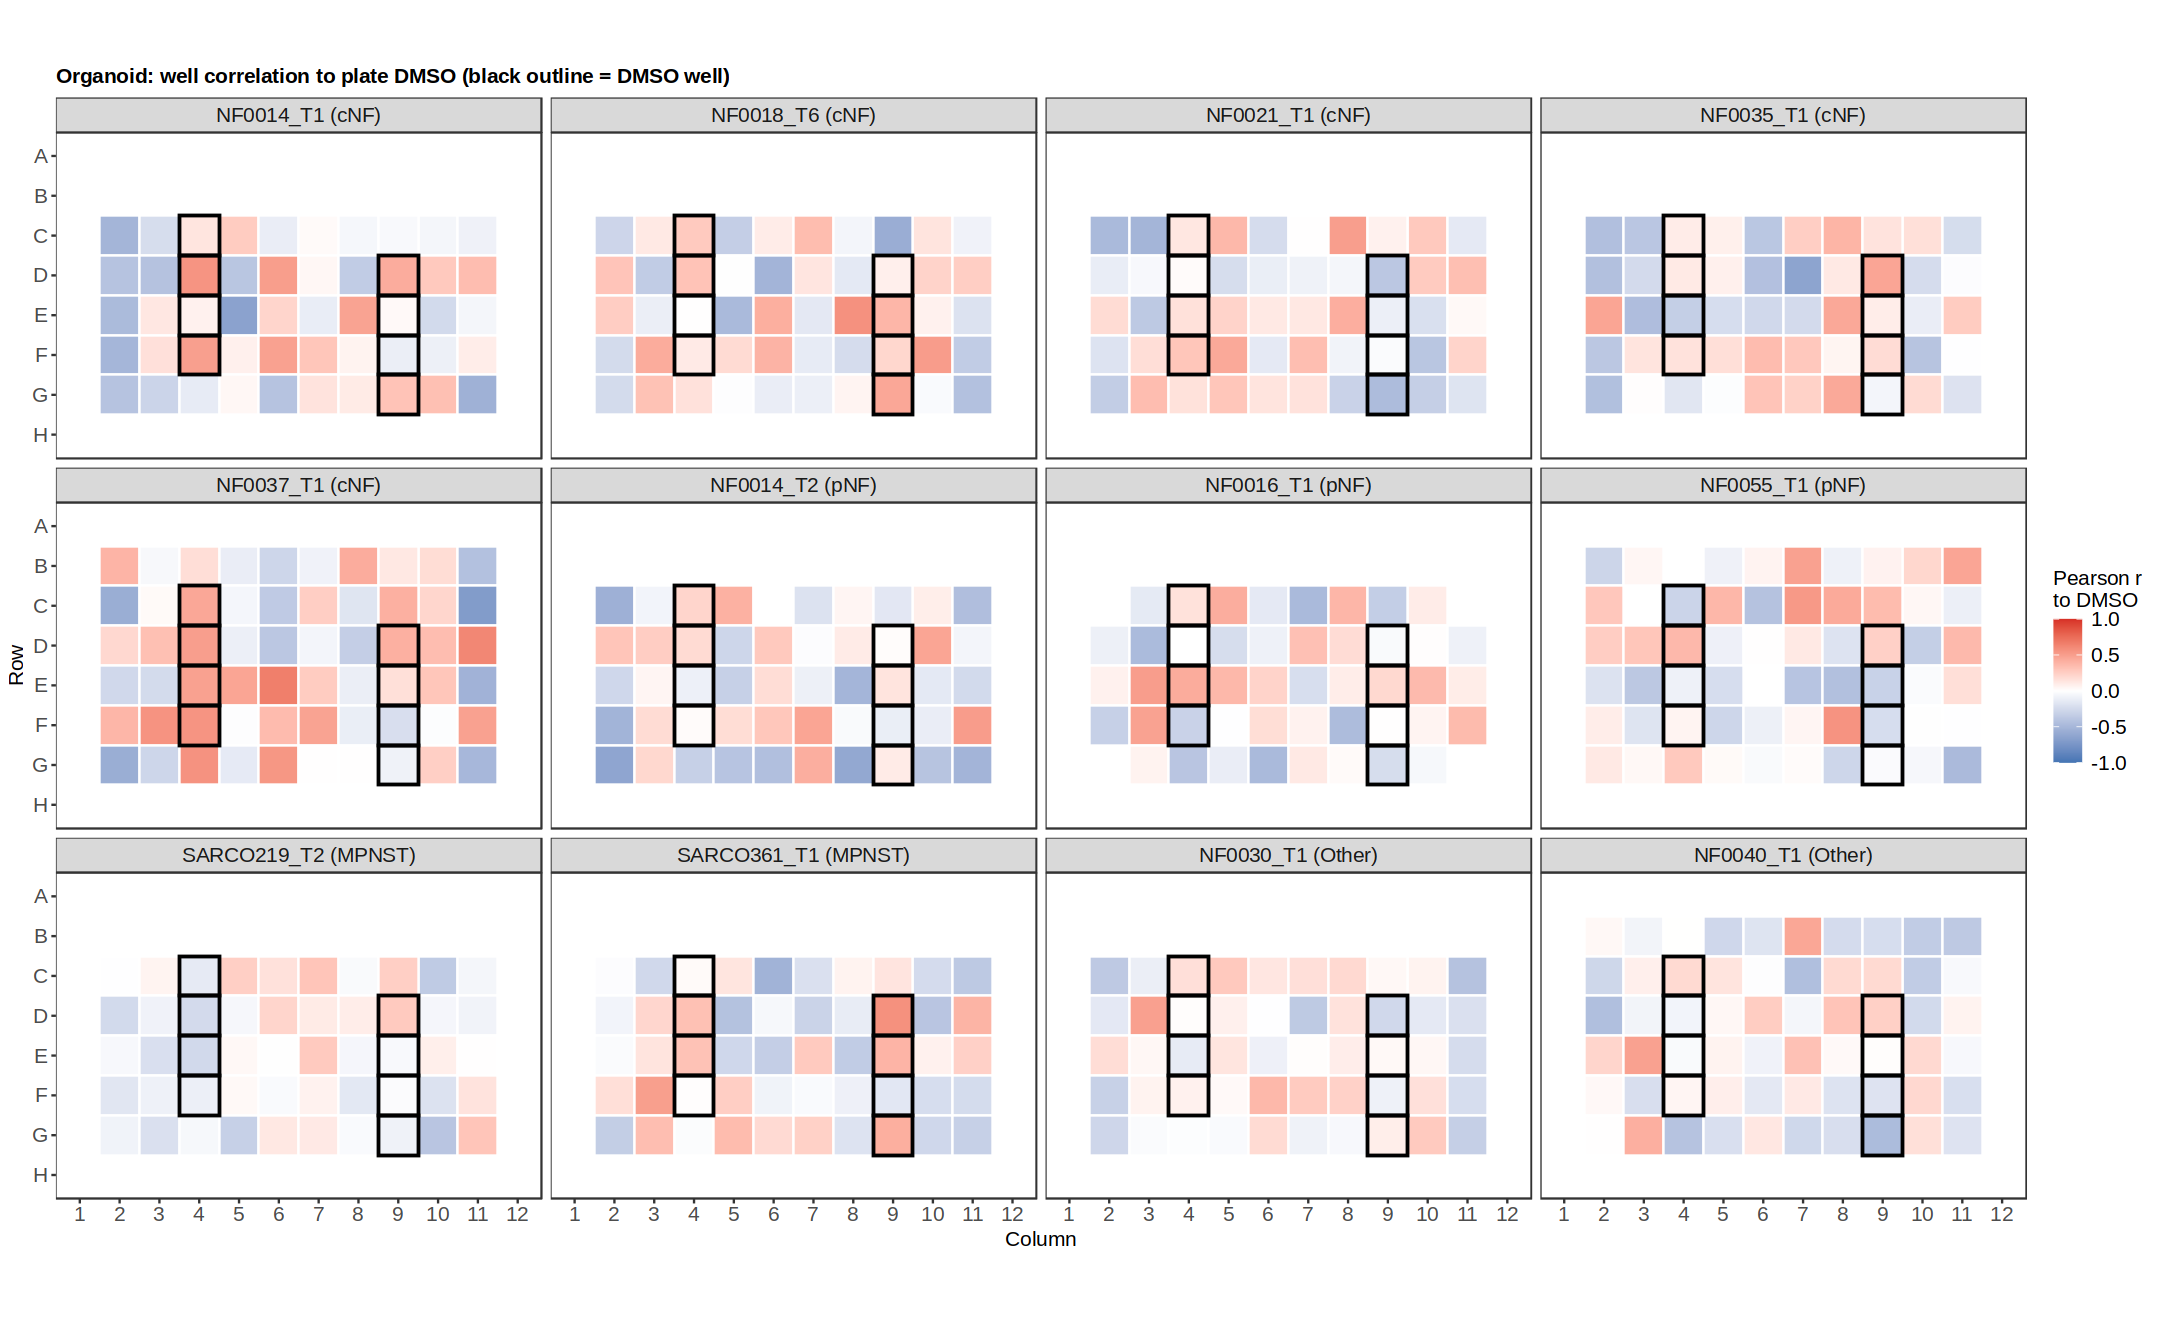

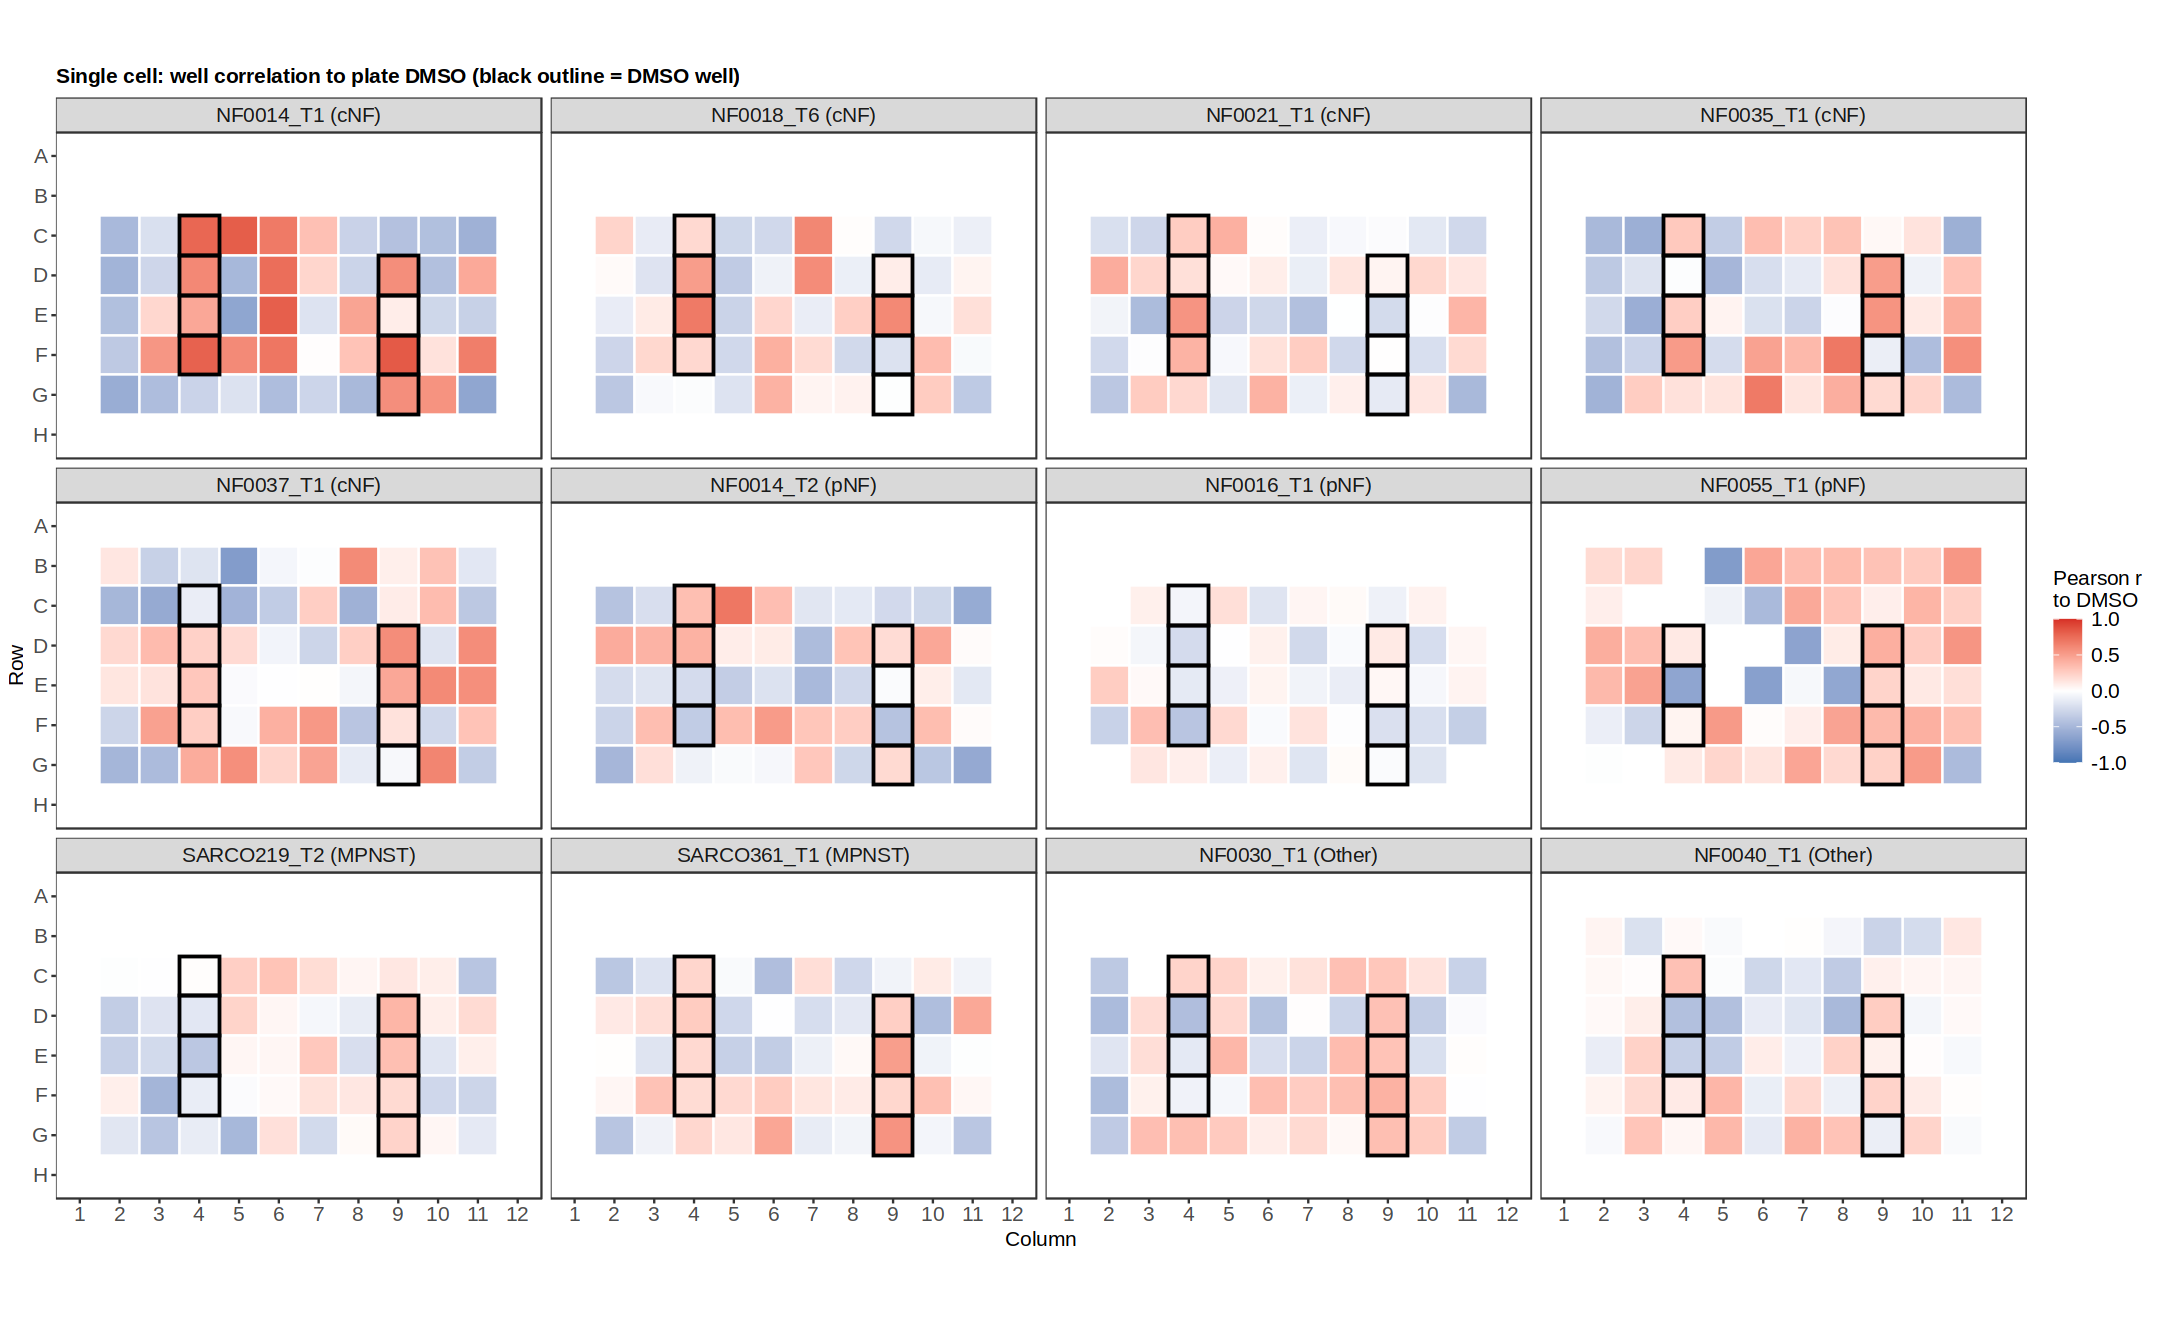

In [4]:
options(repr.plot.width = 18, repr.plot.height = 11)
plate_maps <- lapply(names(compartment_labels), function(compartment_name) {
    plate_df <- correlation_df %>% filter(compartment == compartment_name)
    (
        ggplot(plate_df, aes(x = Metadata_Plate_Column, y = Metadata_Plate_Row, fill = correlation_to_dmso))
        + geom_tile(color = "white", linewidth = 0.5)
        + geom_tile(
            data = plate_df %>% filter(is_dmso),
            color = "black",
            linewidth = 0.8,
            fill = NA
        )
        + scale_fill_gradient2(
            low = correlation_diverging_colours[1],
            mid = correlation_diverging_colours[2],
            high = correlation_diverging_colours[3],
            midpoint = 0,
            limits = c(-1, 1)
        )
        + scale_x_discrete(drop = FALSE)
        + scale_y_discrete(drop = FALSE)
        + coord_fixed()
        + facet_wrap(~patient_label, ncol = 4)
        + labs(
            title = paste0(compartment_labels[[compartment_name]], ": well correlation to plate DMSO (black outline = DMSO well)"),
            x = "Column",
            y = "Row",
            fill = "Pearson r\nto DMSO"
        )
        + theme_manuscript(base_size = 12)
        + theme(panel.grid = element_blank())
    )
})
save_plots_pdf(plate_maps, plate_map_path, width = 18, height = 11)
for (plate_map in plate_maps) print(plate_map)

## Correlation to DMSO per treatment

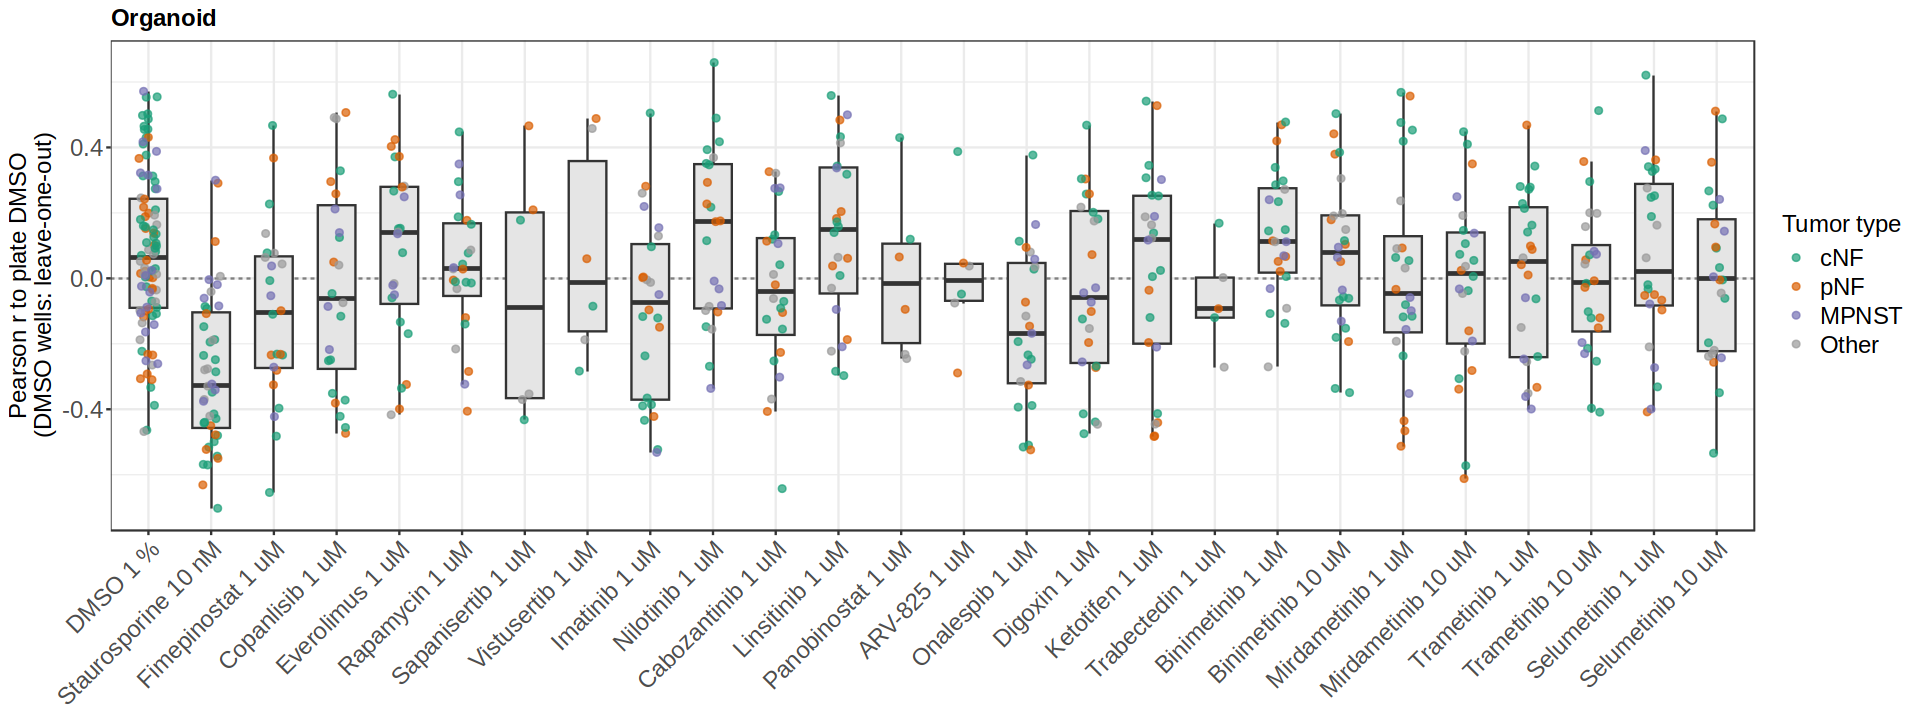

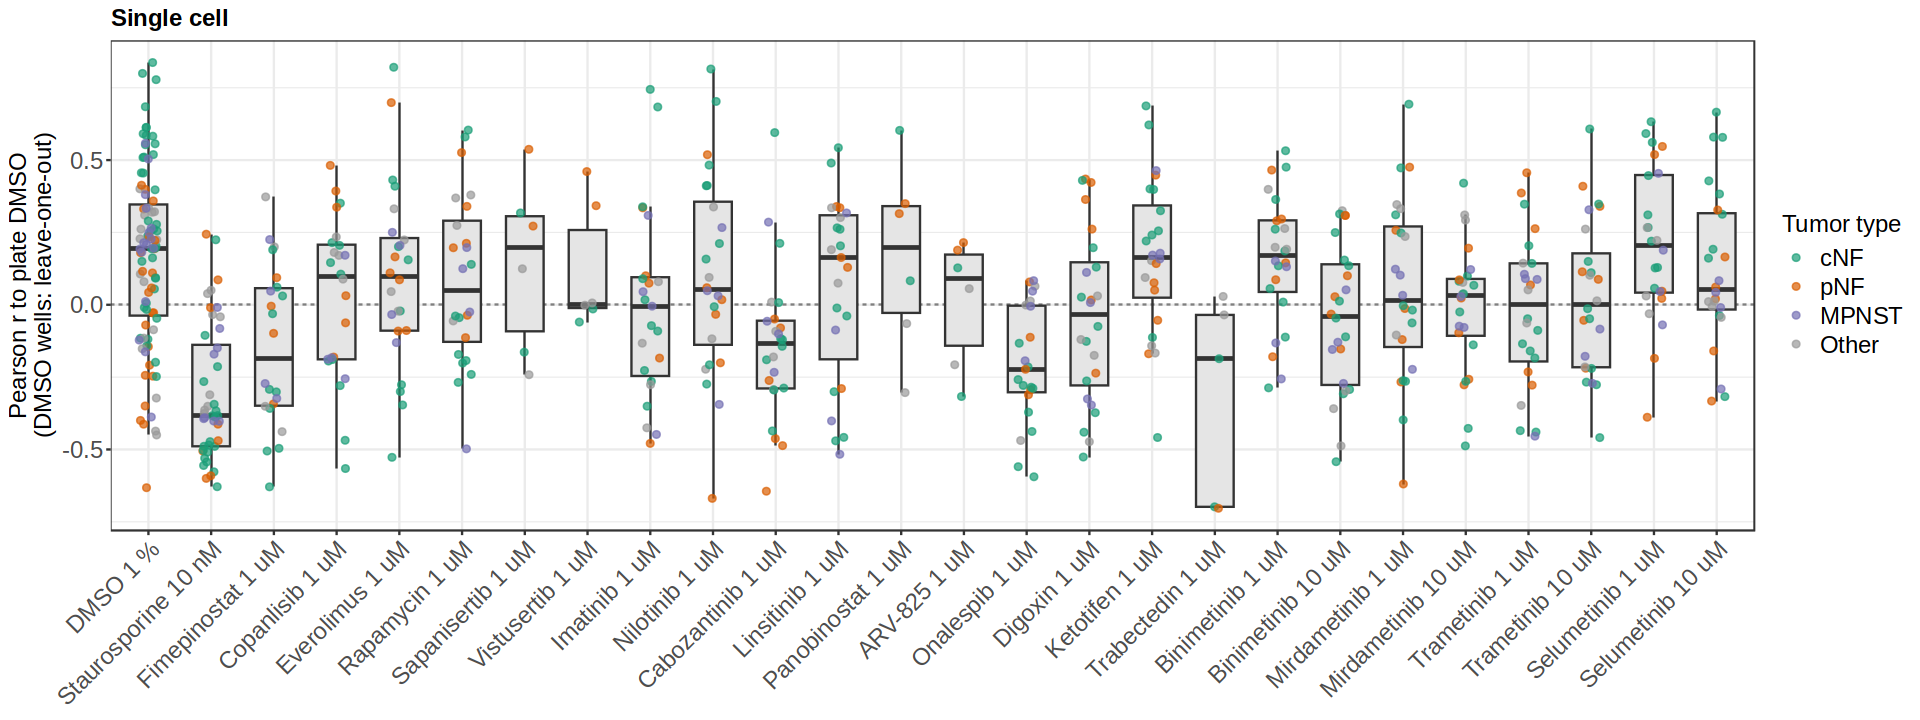

In [5]:
options(repr.plot.width = 16, repr.plot.height = 6)
treatment_plots <- lapply(levels(correlation_df$compartment_label), function(compartment_name) {
    (
        ggplot(
            correlation_df %>% filter(compartment_label == compartment_name),
            aes(x = treatment_label, y = correlation_to_dmso)
        )
        + geom_hline(yintercept = 0, linetype = "dashed", color = "grey50")
        + geom_boxplot(outlier.shape = NA, fill = "grey90", width = 0.6)
        + geom_point(
            aes(color = Metadata_Biology_TumorType),
            size = 1.5,
            alpha = 0.7,
            position = position_jitter(width = 0.15, height = 0, seed = 0)
        )
        + scale_color_manual(values = tumor_type_palette)
        + labs(
            title = compartment_name,
            x = NULL,
            y = "Pearson r to plate DMSO\n(DMSO wells: leave-one-out)",
            color = "Tumor type"
        )
        + theme_manuscript(base_size = 14, x_text = "angled")
    )
})
save_plots_pdf(treatment_plots, treatment_figure_path, width = 16, height = 6)
for (treatment_plot in treatment_plots) print(treatment_plot)